In [ ]:
from pathlib import Path
import yaml
from urllib.parse import urlparse
#import pandas as pd
import os

def load_config(config_path="cfg/config.yaml"):
    with open(config_path, "r") as file:
        config = yaml.safe_load(file)
    return config

folder_path = Path("/root/bigearthnet/BigEarthNet-Models/bigearthnet/explore/results")
folders = [f.name for f in folder_path.iterdir() if f.is_dir()]
print(folders)


['2025-08-19_13-54-49', '2025-08-19_07-45-28', '2025-08-18_15-27-05', '2025-08-22_15-50-07', '2025-08-18_15-12-46', '2025-08-21_13-20-00', '2025-08-19_12-12-40', '2025-08-22_09-35-58', '2025-08-19_15-44-46', '2025-08-23_17-56-57', '2025-08-19_13-52-51', '2025-08-19_12-10-16', '2025-08-19_13-56-23', '2025-08-22_11-41-23', '2025-08-18_14-20-31', '2025-08-21_17-18-40', '2025-08-21_11-46-15', '2025-08-19_07-46-07', '2025-08-19_13-55-20', '2025-08-20_10-00-28', '2025-08-22_15-31-51', '2025-08-22_07-14-22', '2025-08-19_07-00-06', '2025-08-23_10-11-33', '2025-08-21_09-00-23', '2025-08-21_13-04-37', '2025-08-22_11-32-25', '2025-08-20_14-58-01', '2025-08-20_13-29-50', '2025-08-22_00-36-34', '2025-08-20_15-38-05', '2025-08-21_10-17-56', '2025-08-22_02-45-19', '2025-08-20_13-29-13', '2025-08-21_19-21-21', '2025-08-22_07-24-20', '2025-08-21_21-50-41', '2025-08-22_13-00-51', '2025-08-19_08-57-02', '2025-08-21_11-15-47', '2025-08-19_09-29-06', '2025-08-22_08-43-09', '2025-08-23_10-07-14', '2025-08-2

In [ ]:

dict_metrics = {}
dict_folder_name = {}
for folder in folders[:1]:
    parent_folder = os.path.join(folder_path, folder)
    for dir in os.listdir(parent_folder):
        if dir=='config.yaml':
            config= load_config(os.path.join(parent_folder, dir))
            name = f"{config['model']['model_name']}/{config['model']['select_bands']}/{config['training']['learning_rate']}/{config['training']['sensitivity']}/PS{config['training']['positional_weight']}"


config.yaml
{'WANDB': {'project_name': 'NOWorNOW-BigEarthNet-S2-DL-models', 'track': True}, 'datasets': {'img_size': 120, 'metadata_parquet': '/root/bigearthnet/BigEarthNet-Models/df_balanced/teste2.parquet', 'metadata_snow_cloud_parquet': '/root/storage_ds/metadata_snow_cloud.parquet', 'resize': 224, 'root': '~/storage_ds/BigEarthNet-S2', 'upsampling_method': 'bicubic'}, 'model': {'model_name': 'resnet50', 'num_classes': 19, 'pretrained': True, 'select_bands': [3, 2, 1], 'sentinel2_bands': {0: 'B01', 1: 'B02', 2: 'B03', 3: 'B04', 4: 'B05', 5: 'B06', 6: 'B07', 7: 'B08', 8: 'B8A', 9: 'B09', 10: 'B10', 11: 'B11', 12: 'B12'}}, 'training': {'augmentation': False, 'batch_size': 32, 'factor': 0.5, 'learning_rate': '3e-3', 'momentum': True, 'momentum_val': 0.9, 'n_epoch': 80, 'num_workers': 8, 'optim': 'Adam', 'positional_weight': True, 'save_metric': 'f1_score', 'save_mode': 'max', 'save_strategy': 'f1_score', 'scheduler': False, 'scheduler_type': 'ReduceLROnPlateau', 'seed': 41, 'sensitivit

In [127]:
config['training']

{'augmentation': False,
 'batch_size': 32,
 'factor': 0.5,
 'learning_rate': '3e-3',
 'momentum': True,
 'momentum_val': 0.9,
 'n_epoch': 80,
 'num_workers': 8,
 'optim': 'Adam',
 'positional_weight': True,
 'save_metric': 'f1_score',
 'save_mode': 'max',
 'save_strategy': 'f1_score',
 'scheduler': False,
 'scheduler_type': 'ReduceLROnPlateau',
 'seed': 41,
 'sensitivity': 0.51,
 'slice_of_training': 1.0,
 'weight_decay': '1e-3'}

In [122]:
config['model']

{'model_name': 'resnet50',
 'num_classes': 19,
 'pretrained': True,
 'select_bands': [3, 2, 1],
 'sentinel2_bands': {0: 'B01',
  1: 'B02',
  2: 'B03',
  3: 'B04',
  4: 'B05',
  5: 'B06',
  6: 'B07',
  7: 'B08',
  8: 'B8A',
  9: 'B09',
  10: 'B10',
  11: 'B11',
  12: 'B12'}}

In [114]:
config['select_bands']

KeyError: 'select_bands'

In [132]:

dict_metrics = {}
dict_folder_name = {}
for folder in folders[:5]:
    parent_folder = os.path.join(folder_path, folder)
    for dir in os.listdir(parent_folder):
        if dir=='metrics':
            metric_child = os.path.join(parent_folder,dir) 
            if len(os.listdir(metric_child))>0:
                list_metrics = os.listdir(metric_child)
                for metric in list_metrics:
                    path_metric = os.path.join(metric_child,metric)
                    
                    ## Open DF
                    try:
                        df = pd.read_csv(path_metric)
                        print(metric)
                        print(df.shape)
                    except:
                        pass
                    
                    if len(df.shape)>0:
                        try:
                            dict_metrics[metric.split('.')[0]] = df
                            print(metric.split('.')[0])
                        except:
                            print(f"error at: {path_metric}")
                    
        if dir=='config.yaml':
            config= load_config(os.path.join(parent_folder, dir))
            name = f"{config['model']['model_name']}/{config['model']['select_bands']}/{config['training']['learning_rate']}/{config['training']['sensitivity']}/PS{config['training']['positional_weight']}"

    if len(dict_metrics.keys())>1:
        dict_folder_name[name] = dict_metrics
        ## load config file and describe the model 
        # else:
        #     try:
        #         config_file = load_config(os.path.join(parent_folder, 'config.yaml'))
        #         print(config_file['training'])
        #     except:
        #         non_config = True

f1_score_metrics.csv
(11, 3)
f1_score_metrics
accuracy_metrics.csv
(11, 3)
accuracy_metrics
precision_metrics.csv
(11, 3)
precision_metrics
test_metrics_summary.csv
(1, 4)
test_metrics_summary
recall_metrics.csv
(11, 3)
recall_metrics
losses.csv
(11, 3)
losses


In [193]:
dict_metrics = {}
dict_folder_name = {}
for folder in folders:
    parent_folder = os.path.join(folder_path, folder)
    dict_metrics = {}  # Reset for each folder
    name = None  # Initialize name
    
    for dir in os.listdir(parent_folder):
        if dir=='metrics':
            metric_child = os.path.join(parent_folder,dir) 
            # Check if metrics folder has files
            if os.listdir(metric_child):  # This handles empty folder
                list_metrics = os.listdir(metric_child)
                for metric in list_metrics:
                    path_metric = os.path.join(metric_child,metric)
                    
                    ## Open DF
                    try:
                        df = pd.read_csv(path_metric)
                       # print(metric)
                        #print(df.shape)
                        
                        if len(df.shape)>0:
                            dict_metrics[metric.split('.')[0]] = df
                            #print(metric.split('.')[0])
                    except:
                        print(f"error at: {path_metric}")
                    
        if dir=='config.yaml':
            try:
                config = load_config(os.path.join(parent_folder, dir))
                name = f"{config['model']['model_name']}/{config['model']['select_bands']}/{config['training']['learning_rate']}/{config['training']['sensitivity']}/PS{config['training']['positional_weight']}"
            except:
                print(f"error loading config in: {parent_folder}")
                name = None

    # Only add if we have both metrics and config name
    if len(dict_metrics.keys())>1 and name is not None:
        dict_metrics['name_folder'] = folder
        dict_folder_name[name] = dict_metrics

In [194]:
len(dict_folder_name.keys())

11

In [ ]:
# # Create separate dataframes for each metric type
# f1_df = None
# accuracy_df = None
# precision_df = None
# recall_df = None
# losses_df = None

# for config_name, metrics_dict in dict_folder_name.items():
    
#     # Process F1 scores
#     if 'f1_score_metrics' in metrics_dict:
#         df = metrics_dict['f1_score_metrics'].copy()
#         df['config'] = config_name
#         if f1_df is None:
#             f1_df = df
#         else:
#             f1_df = pd.concat([f1_df, df], ignore_index=True)
    
#     # Process Accuracy
#     if 'accuracy_metrics' in metrics_dict:
#         df = metrics_dict['accuracy_metrics'].copy()
#         df['config'] = config_name
#         if accuracy_df is None:
#             accuracy_df = df
#         else:
#             accuracy_df = pd.concat([accuracy_df, df], ignore_index=True)
    
#     # Process Precision
#     if 'precision_metrics' in metrics_dict:
#         df = metrics_dict['precision_metrics'].copy()
#         df['config'] = config_name
#         if precision_df is None:
#             precision_df = df
#         else:
#             precision_df = pd.concat([precision_df, df], ignore_index=True)
    
#     # Process Recall
#     if 'recall_metrics' in metrics_dict:
#         df = metrics_dict['recall_metrics'].copy()
#         df['config'] = config_name
#         if recall_df is None:
#             recall_df = df
#         else:
#             recall_df = pd.concat([recall_df, df], ignore_index=True)
    
#     # Process Losses
#     if 'losses' in metrics_dict:
#         df = metrics_dict['losses'].copy()
#         df['config'] = config_name
#         if losses_df is None:
#             losses_df = df
#         else:
#             losses_df = pd.concat([losses_df, df], axis=1,ignore_index=False)

# Now you have separate dataframes: f1_df, accuracy_df, precision_df, recall_df, losses_df
# Each contains all configs with a 'config' column to identify the model

##  Concat all dfs

In [195]:
# Create separate dataframes for train and val metrics
train_f1_df = None
val_f1_df = None
train_accuracy_df = None
val_accuracy_df = None
train_precision_df = None
val_precision_df = None
train_recall_df = None
val_recall_df = None
train_losses_df = None
val_losses_df = None

for config_name, metrics_dict in dict_folder_name.items():
    
    # Process F1 scores
    if 'f1_score_metrics' in metrics_dict:
        df = metrics_dict['f1_score_metrics'].copy()
        train_f1 = df[['epoch', 'train_f1_score']].rename(columns={'train_f1_score': config_name})
        val_f1 = df[['epoch', 'val_f1_score']].rename(columns={'val_f1_score': config_name})
        
        if train_f1_df is None:
            train_f1_df = train_f1
        else:
            train_f1_df = pd.concat([train_f1_df, train_f1[config_name]], axis=1)
            
        if val_f1_df is None:
            val_f1_df = val_f1
        else:
            val_f1_df = pd.concat([val_f1_df, val_f1[config_name]], axis=1)
    
    # Process Accuracy
    if 'accuracy_metrics' in metrics_dict:
        df = metrics_dict['accuracy_metrics'].copy()
        train_acc = df[['epoch', 'train_accuracy']].rename(columns={'train_accuracy': config_name})
        val_acc = df[['epoch', 'val_accuracy']].rename(columns={'val_accuracy': config_name})
        
        if train_accuracy_df is None:
            train_accuracy_df = train_acc
        else:
            train_accuracy_df = pd.concat([train_accuracy_df, train_acc[config_name]], axis=1)
            
        if val_accuracy_df is None:
            val_accuracy_df = val_acc
        else:
            val_accuracy_df = pd.concat([val_accuracy_df, val_acc[config_name]], axis=1)
    
    # Process Precision
    if 'precision_metrics' in metrics_dict:
        df = metrics_dict['precision_metrics'].copy()
        train_prec = df[['epoch', 'train_precision']].rename(columns={'train_precision': config_name})
        val_prec = df[['epoch', 'val_precision']].rename(columns={'val_precision': config_name})
        
        if train_precision_df is None:
            train_precision_df = train_prec
        else:
            train_precision_df = pd.concat([train_precision_df, train_prec[config_name]], axis=1)
            
        if val_precision_df is None:
            val_precision_df = val_prec
        else:
            val_precision_df = pd.concat([val_precision_df, val_prec[config_name]], axis=1)
    
    # Process Recall
    if 'recall_metrics' in metrics_dict:
        df = metrics_dict['recall_metrics'].copy()
        train_rec = df[['epoch', 'train_recall']].rename(columns={'train_recall': config_name})
        val_rec = df[['epoch', 'val_recall']].rename(columns={'val_recall': config_name})
        
        if train_recall_df is None:
            train_recall_df = train_rec
        else:
            train_recall_df = pd.concat([train_recall_df, train_rec[config_name]], axis=1)
            
        if val_recall_df is None:
            val_recall_df = val_rec
        else:
            val_recall_df = pd.concat([val_recall_df, val_rec[config_name]], axis=1)
    
    # Process Losses
    if 'losses' in metrics_dict:
        df = metrics_dict['losses'].copy()
        train_loss = df[['epoch', 'train_loss']].rename(columns={'train_loss': config_name})
        val_loss = df[['epoch', 'val_loss']].rename(columns={'val_loss': config_name})
        
        if train_losses_df is None:
            train_losses_df = train_loss
        else:
            train_losses_df = pd.concat([train_losses_df, train_loss[config_name]], axis=1)
            
        if val_losses_df is None:
            val_losses_df = val_loss
        else:
            val_losses_df = pd.concat([val_losses_df, val_loss[config_name]], axis=1)

# Now you have separate dataframes for train and validation metrics
# Each dataframe has 'epoch' as index and config names as column headers
# train_precision_df: columns are config names, rows are epochs, values are train precision scores
# val_precision_df: columns are config names, rows are epochs, values are val precision scores

In [214]:
import re
def extract_float_from_tensor_string(x):
    if isinstance(x, str) and 'tensor(' in x:
        # Extract number between parentheses
        match = re.search(r'tensor\(([\d.-]+)', str(x))
        if match:
            return float(match.group(1))
    return x

val_recall_df_float = val_recall_df.applymap(extract_float_from_tensor_string)


/tmp/ipykernel_3171714/3339105560.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  val_recall_df_float = val_recall_df.applymap(extract_float_from_tensor_string)


In [215]:
val_recall_df_float

,epoch,"vit_base_patch16_siglip_gap_224/[0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12]/1e-3/0.45/PSTrue","resnet50/[0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 11, 12]/1e-3/0.51/PSTrue","resnet50/[1, 2, 3, 4, 11]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 11, 12]/1e-3/0.43/PSTrue","resnet50/[1, 2, 3, 4, 5, 6, 11, 12]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 5, 6, 7, 11, 12]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12]/1e-3/0.55/PSTrue","resnet50/[3, 2, 1]/1e-3/0.55/PSTrue","resnet50/[3, 2, 1]/1e-3/0.69/PSTrue"
0,0.0,0.4559,0.5565,0.4476,0.3955,0.5138,0.4772,0.5179,0.5354,0.5386,0.4434,0.2583
1,1.0,0.4027,0.5832,0.5336,0.3926,0.5911,0.4797,0.6009,0.5721,0.5837,0.5026,0.2338
2,2.0,0.3518,0.5976,0.5645,0.4608,0.5799,0.5478,0.6028,0.5758,0.5936,0.5415,0.2087
3,3.0,0.3428,0.5950,0.5719,0.4835,0.5925,0.5622,0.6103,0.6273,0.6259,0.5685,0.2524
4,4.0,0.4181,0.6326,0.5811,0.5173,0.6219,0.5987,0.6609,0.6347,0.6445,0.5841,0.1403
...,...,...,...,...,...,...,...,...,...,...,...,...
75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3689
76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3602
77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3785
78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3180


In [ ]:
train_f1_df = None
val_f1_df = None
train_accuracy_df = None
val_accuracy_df = None
train_precision_df = None
val_precision_df = None
train_recall_df = None
val_recall_df = val_recall_df.applymap(extract_float_from_tensor_string)
train_losses_df = None
val_losses_df = None

,epoch,"vit_base_patch16_siglip_gap_224/[0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12]/1e-3/0.45/PSTrue","resnet50/[0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 11, 12]/1e-3/0.51/PSTrue","resnet50/[1, 2, 3, 4, 11]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 11, 12]/1e-3/0.43/PSTrue","resnet50/[1, 2, 3, 4, 5, 6, 11, 12]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 5, 6, 7, 11, 12]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12]/1e-3/0.55/PSTrue","resnet50/[3, 2, 1]/1e-3/0.55/PSTrue","resnet50/[3, 2, 1]/1e-3/0.69/PSTrue"
0,0.0,"tensor(0.4506, device='cuda:0')","tensor(0.5309, device='cuda:0')","tensor(0.4785, device='cuda:0')","tensor(0.4028, device='cuda:0')","tensor(0.5050, device='cuda:0')","tensor(0.4531, device='cuda:0')","tensor(0.5192, device='cuda:0')","tensor(0.5266, device='cuda:0')","tensor(0.5281, device='cuda:0')","tensor(0.4377, device='cuda:0')","tensor(0.3466, device='cuda:0')"
1,1.0,"tensor(0.4234, device='cuda:0')","tensor(0.6308, device='cuda:0')","tensor(0.5976, device='cuda:0')","tensor(0.4714, device='cuda:0')","tensor(0.6176, device='cuda:0')","tensor(0.5095, device='cuda:0')","tensor(0.6263, device='cuda:0')","tensor(0.6276, device='cuda:0')","tensor(0.6324, device='cuda:0')","tensor(0.5516, device='cuda:0')","tensor(0.3671, device='cuda:0')"
2,2.0,"tensor(0.3934, device='cuda:0')","tensor(0.6705, device='cuda:0')","tensor(0.6368, device='cuda:0')","tensor(0.5049, device='cuda:0')","tensor(0.6535, device='cuda:0')","tensor(0.5374, device='cuda:0')","tensor(0.6687, device='cuda:0')","tensor(0.6671, device='cuda:0')","tensor(0.6708, device='cuda:0')","tensor(0.6011, device='cuda:0')","tensor(0.4066, device='cuda:0')"
3,3.0,"tensor(0.4152, device='cuda:0')","tensor(0.6923, device='cuda:0')","tensor(0.6655, device='cuda:0')","tensor(0.5190, device='cuda:0')","tensor(0.6787, device='cuda:0')","tensor(0.5511, device='cuda:0')","tensor(0.6886, device='cuda:0')","tensor(0.6911, device='cuda:0')","tensor(0.6913, device='cuda:0')","tensor(0.6331, device='cuda:0')","tensor(0.4269, device='cuda:0')"
4,4.0,"tensor(0.4073, device='cuda:0')","tensor(0.7104, device='cuda:0')","tensor(0.6819, device='cuda:0')","tensor(0.5295, device='cuda:0')","tensor(0.6955, device='cuda:0')","tensor(0.5596, device='cuda:0')","tensor(0.7094, device='cuda:0')","tensor(0.7099, device='cuda:0')","tensor(0.7123, device='cuda:0')","tensor(0.6612, device='cuda:0')","tensor(0.4393, device='cuda:0')"
...,...,...,...,...,...,...,...,...,...,...,...,...
75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"tensor(0.4765, device='cuda:0')"
76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"tensor(0.4752, device='cuda:0')"
77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"tensor(0.4786, device='cuda:0')"
78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"tensor(0.4768, device='cuda:0')"


In [217]:
train_f1_df = train_f1_df.applymap(extract_float_from_tensor_string) if train_f1_df is not None else None
val_f1_df = val_f1_df.applymap(extract_float_from_tensor_string) if val_f1_df is not None else None
train_accuracy_df = train_accuracy_df.applymap(extract_float_from_tensor_string) if train_accuracy_df is not None else None
val_accuracy_df = val_accuracy_df.applymap(extract_float_from_tensor_string) if val_accuracy_df is not None else None
train_precision_df = train_precision_df.applymap(extract_float_from_tensor_string) if train_precision_df is not None else None
val_precision_df = val_precision_df.applymap(extract_float_from_tensor_string) if val_precision_df is not None else None
train_recall_df = train_recall_df.applymap(extract_float_from_tensor_string) if train_recall_df is not None else None
val_recall_df = val_recall_df.applymap(extract_float_from_tensor_string)
#train_losses_df = train_losses_df.applymap(extract_float_from_tensor_string) if train_losses_df is not None else None
#val_losses_df = val_losses_df.applymap(extract_float_from_tensor_string) if val_losses_df is not None else None


/tmp/ipykernel_3171714/469827255.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_f1_df = train_f1_df.applymap(extract_float_from_tensor_string) if train_f1_df is not None else None
/tmp/ipykernel_3171714/469827255.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  val_f1_df = val_f1_df.applymap(extract_float_from_tensor_string) if val_f1_df is not None else None
/tmp/ipykernel_3171714/469827255.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_accuracy_df = train_accuracy_df.applymap(extract_float_from_tensor_string) if train_accuracy_df is not None else None
/tmp/ipykernel_3171714/469827255.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  val_accuracy_df = val_accuracy_df.applymap(extract_float_from_tensor_string) if val_accuracy_df is not None else None
/tmp/ipykernel_3171714/469827255.py:5: FutureWarning: DataFr

In [220]:
train_losses_df

,epoch,"vit_base_patch16_siglip_gap_224/[0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12]/1e-3/0.45/PSTrue","resnet50/[0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 11, 12]/1e-3/0.51/PSTrue","resnet50/[1, 2, 3, 4, 11]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 11, 12]/1e-3/0.43/PSTrue","resnet50/[1, 2, 3, 4, 5, 6, 11, 12]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 5, 6, 7, 11, 12]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12]/1e-3/0.55/PSTrue","resnet50/[3, 2, 1]/1e-3/0.55/PSTrue","resnet50/[3, 2, 1]/1e-3/0.69/PSTrue"
0,0.0,0.415200,0.353415,0.378661,0.414100,0.365608,0.414100,0.358462,0.355861,0.353051,0.398531,0.384022
1,1.0,0.423746,0.294046,0.316524,0.379616,0.304582,0.379616,0.298419,0.297142,0.293784,0.339868,0.371000
2,2.0,0.430665,0.269719,0.292743,0.361706,0.282317,0.361706,0.273612,0.271432,0.269609,0.311688,0.355636
3,3.0,0.422814,0.254103,0.275429,0.354489,0.265897,0.354489,0.257536,0.254986,0.254079,0.292429,0.349319
4,4.0,0.425504,0.241619,0.262802,0.349723,0.254177,0.349723,0.244833,0.243176,0.241429,0.277235,0.344403
...,...,...,...,...,...,...,...,...,...,...,...,...
75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.329369
76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.328316
77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.327876
78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.327729


## SAVE

In [221]:
dataframes_list = [
    ("train_f1_df", train_f1_df),
    ("val_f1_df", val_f1_df),
    ("train_accuracy_df", train_accuracy_df),
    ("val_accuracy_df", val_accuracy_df),
    ("train_precision_df", train_precision_df),
    ("val_precision_df", val_precision_df),
    ("train_recall_df", train_recall_df),
    ("val_recall_df", val_recall_df),
    ("train_losses_df", train_losses_df),
    ("val_losses_df", val_losses_df)
]

In [223]:
os.getcwd()

'/root/bigearthnet/BigEarthNet-Models/bigearthnet/explore'

In [241]:
for df_name, df in dataframes_list:
    if df is not None:
        filename = f"{df_name}.csv"
        path = os.path.join("/root/bigearthnet/BigEarthNet-Models/bigearthnet/explore/results_df_csv",filename)
        df.to_csv(path, index=True)
        print(f"✓ Saved {df_name} to {filename}")
    else:
        print(f"✗ Skipped {df_name} (was None)")

✓ Saved train_f1_df to train_f1_df.csv
✓ Saved val_f1_df to val_f1_df.csv
✓ Saved train_accuracy_df to train_accuracy_df.csv
✓ Saved val_accuracy_df to val_accuracy_df.csv
✓ Saved train_precision_df to train_precision_df.csv
✓ Saved val_precision_df to val_precision_df.csv
✓ Saved train_recall_df to train_recall_df.csv
✓ Saved val_recall_df to val_recall_df.csv
✓ Saved train_losses_df to train_losses_df.csv
✓ Saved val_losses_df to val_losses_df.csv


## TESTE PLOTS!! 

In [188]:
val_losses_df.shape[1]

11

In [204]:
# Set style for beautiful plots
plt.style.use('seaborn-v0_8-darkgrid')  # or 'seaborn-v0_8-whitegrid' if you prefer
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

def plot_df(df):
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 8))

    # Define beautiful colors for each line
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#A663CC', '#FF6B35', '#004E89']

    # Plot each model
    for i, column in enumerate(df.columns):
        if column != 'epoch':  # Skip epoch column
            # Split the column name to extract components
            parts = column.split('/')
            model_name = parts[0]  # e.g., 'vit_base_patch16_siglip_gap_224'
            bands_list = parts[1]  # e.g., '[0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12]'
            learning_rate = parts[2]  # e.g., '1e-3'
            sensitivity = parts[3]  # e.g., '0.45'
            
            # Extract model type (VIT, ResNet, etc.)
            if 'vit' in model_name.lower():
                model_type = 'VIT'
            elif 'resnet' in model_name.lower():
                model_type = 'ResNet'
            else:
                model_type = model_name.upper()
            
            # Count number of bands by counting commas + 1 in the list string
            num_bands = bands_list.count(',') + 1
            
            # Create the label: ModelType-NumberOfBands-Sensitivity
            label = f"{model_type}-{num_bands}-{sensitivity}"
            
            # Plot the line with beautiful styling
            ax.plot(df.index, df[column], 
                    color=colors[i % len(colors)], 
                    linewidth=3, 
                    marker='o', 
                    markersize=6,
                    alpha=0.8,
                    label=label,
                    markerfacecolor='white',
                    markeredgewidth=2,
                    markeredgecolor=colors[i % len(colors)])

    # Customize the plot
    ax.set_xlabel('Epoch', fontweight='bold', fontsize=14)
    ax.set_ylabel('Validation Loss', fontweight='bold', fontsize=14)
    ax.set_title('Model Validation Loss Comparison', fontweight='bold', fontsize=18, pad=20)

    # Set grid
    ax.grid(True, alpha=0.3, linestyle='--')

    # Customize legend
    legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', 
                    frameon=True, fancybox=True, shadow=True, 
                    borderpad=1, columnspacing=1)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)

    # Set axis limits with some padding
    ax.set_xlim(-0.5, 25+ 0.5)

    # Add subtle background gradient
    ax.set_facecolor('#f8f9fa')

    # Add minor ticks
    ax.minorticks_on()
    ax.tick_params(which='minor')

    # Adjust layout to prevent legend cutoff
    plt.tight_layout()

    # Add annotation for best performing model at the end
    final_epoch_idx = df.index.max()
    final_losses = {}
    for column in df.columns:
        if column != 'epoch':
            final_loss = df.loc[final_epoch_idx, column]
            if not pd.isna(final_loss):
                final_losses[column] = final_loss

    if final_losses:
        best_model = max(final_losses, key=final_losses.get)
        best_loss = final_losses[best_model]
        best_model_short = best_model.split('/')[0]
        
        ax.annotate(f'Best: {best_model_short}\n{best_loss:.4f}', 
                    xy=(final_epoch_idx, best_loss), 
                    xytext=(final_epoch_idx - 2, best_loss + 0.02),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2),
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8),
                    fontsize=10, fontweight='bold')

    plt.show()


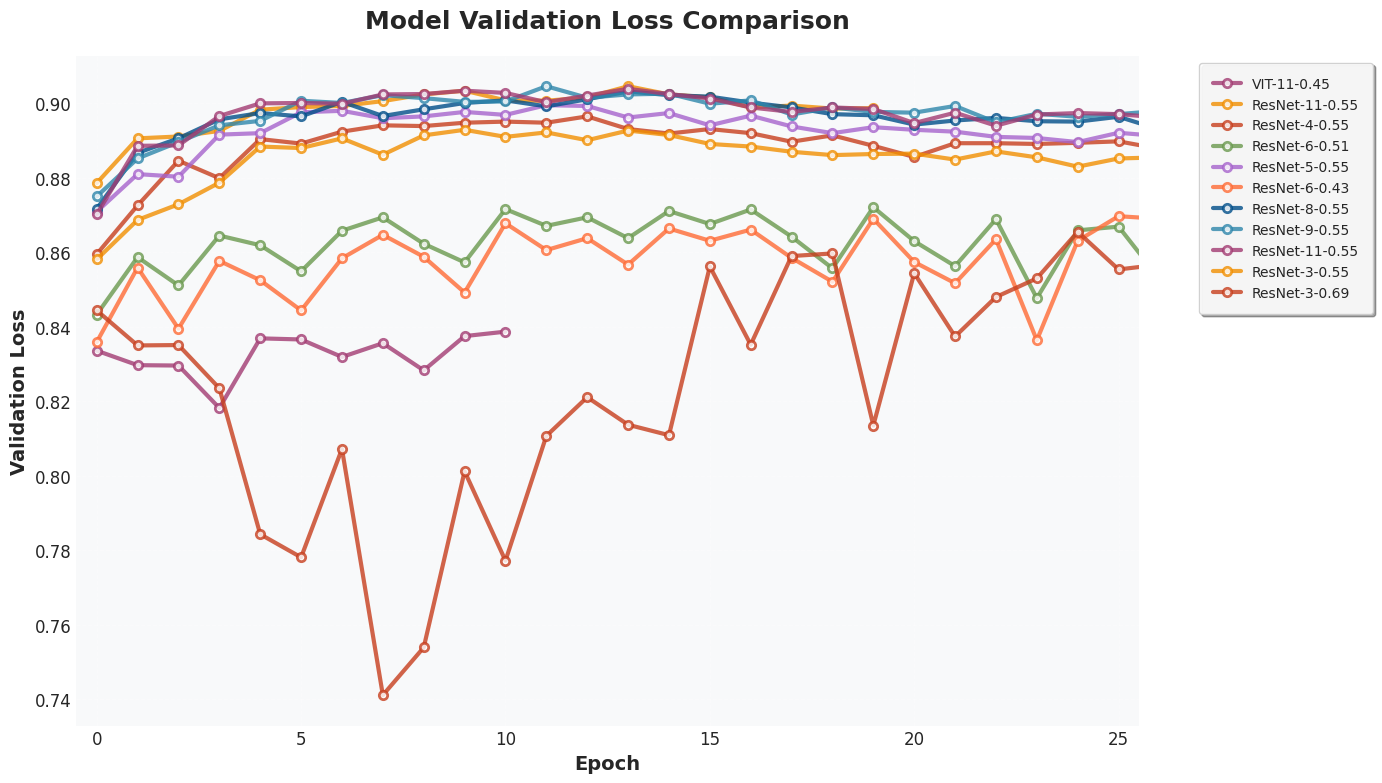

In [ ]:
plot_df(val_accuracy_df, " ")

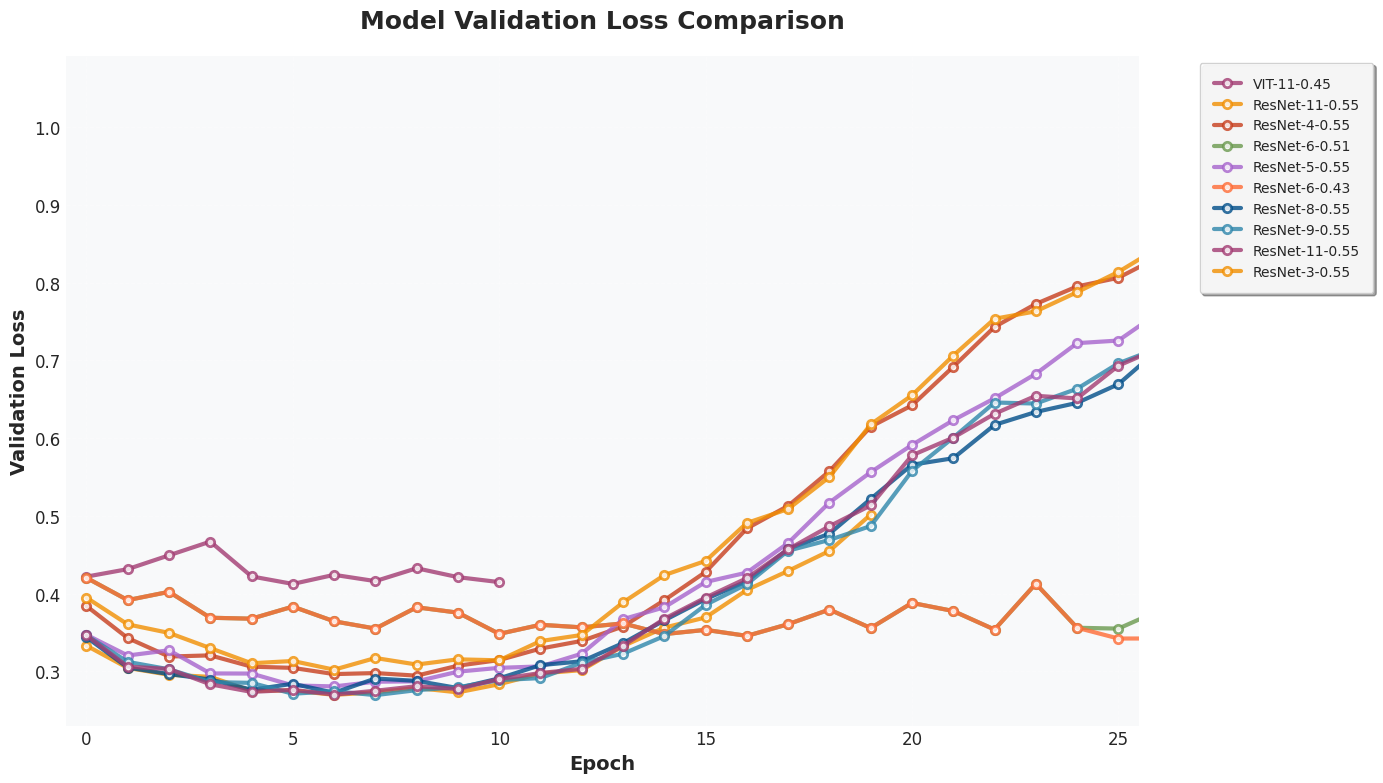

In [192]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# Set style for beautiful plots
plt.style.use('seaborn-v0_8-darkgrid')  # or 'seaborn-v0_8-whitegrid' if you prefer
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Define beautiful colors for each line
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#A663CC', '#FF6B35', '#004E89']

# Plot each model
for i, column in enumerate(val_losses_df.columns):
    if column != 'epoch':  # Skip epoch column
        # Split the column name to extract components
        parts = column.split('/')
        model_name = parts[0]  # e.g., 'vit_base_patch16_siglip_gap_224'
        bands_list = parts[1]  # e.g., '[0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12]'
        learning_rate = parts[2]  # e.g., '1e-3'
        sensitivity = parts[3]  # e.g., '0.45'
        
        # Extract model type (VIT, ResNet, etc.)
        if 'vit' in model_name.lower():
            model_type = 'VIT'
        elif 'resnet' in model_name.lower():
            model_type = 'ResNet'
        else:
            model_type = model_name.upper()
        
        # Count number of bands by counting commas + 1 in the list string
        num_bands = bands_list.count(',') + 1
        
        # Create the label: ModelType-NumberOfBands-Sensitivity
        label = f"{model_type}-{num_bands}-{sensitivity}"
        
        # Plot the line with beautiful styling
        ax.plot(val_losses_df.index, val_losses_df[column], 
                color=colors[i % len(colors)], 
                linewidth=3, 
                marker='o', 
                markersize=6,
                alpha=0.8,
                label=label,
                markerfacecolor='white',
                markeredgewidth=2,
                markeredgecolor=colors[i % len(colors)])

# Customize the plot
ax.set_xlabel('Epoch', fontweight='bold', fontsize=14)
ax.set_ylabel('Validation Loss', fontweight='bold', fontsize=14)
ax.set_title('Model Validation Loss Comparison', fontweight='bold', fontsize=18, pad=20)

# Set grid
ax.grid(True, alpha=0.3, linestyle='--')

# Customize legend
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', 
                   frameon=True, fancybox=True, shadow=True, 
                   borderpad=1, columnspacing=1)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Set axis limits with some padding
ax.set_xlim(-0.5, 25+ 0.5)

# Add subtle background gradient
ax.set_facecolor('#f8f9fa')

# Add minor ticks
ax.minorticks_on()
ax.tick_params(which='minor')

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Add annotation for best performing model at the end
final_epoch_idx = val_losses_df.index.max()
final_losses = {}
for column in val_losses_df.columns:
    if column != 'epoch':
        final_loss = val_losses_df.loc[final_epoch_idx, column]
        if not pd.isna(final_loss):
            final_losses[column] = final_loss

if final_losses:
    best_model = max(final_losses, key=final_losses.get)
    best_loss = final_losses[best_model]
    best_model_short = best_model.split('/')[0]
    
    ax.annotate(f'Best: {best_model_short}\n{best_loss:.4f}', 
                xy=(final_epoch_idx, best_loss), 
                xytext=(final_epoch_idx - 2, best_loss + 0.02),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8),
                fontsize=10, fontweight='bold')

plt.show()

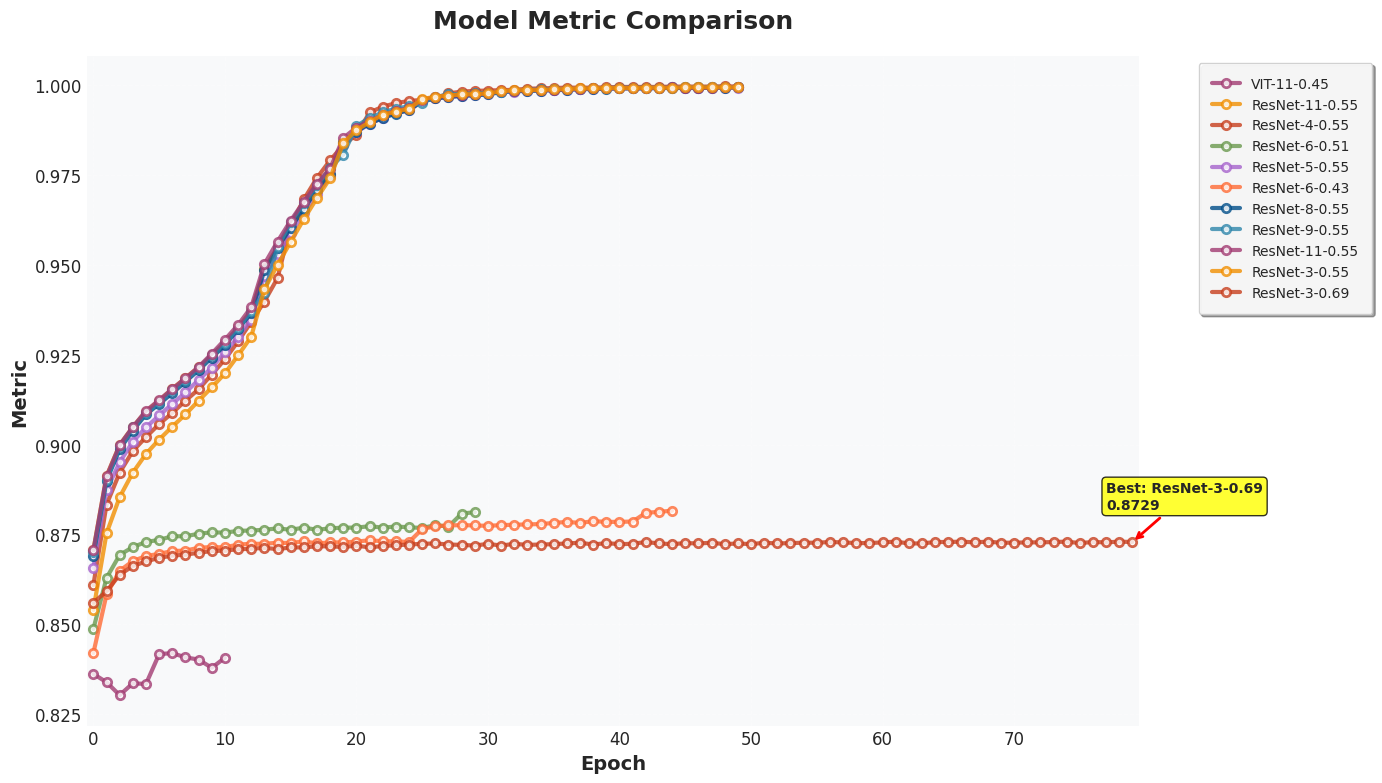

In [228]:
plot_metrics(train_accuracy_df)

In [233]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

def plot_metrics(df, max_x_limit=None, title="Model Metrics Comparison", ylabel="Metric Value", 
                 figsize=(14, 8), find_best="min"):
    """
    Plot model metrics comparison with beautiful styling.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with metrics where columns are model configs and rows are epochs
    max_x_limit : int, optional
        Maximum x-axis limit. If None, uses df.index.max()
    title : str
        Plot title
    ylabel : str
        Y-axis label
    figsize : tuple
        Figure size (width, height)
    find_best : str
        'min' to find minimum value as best, 'max' for maximum
    """
    
    # Set style for beautiful plots
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.rcParams['figure.figsize'] = figsize
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['legend.fontsize'] = 10
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12

    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)

    # Define beautiful colors for each line
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#A663CC', '#FF6B35', '#004E89']

    # Plot each model
    for i, column in enumerate(df.columns):
        if column != 'epoch':  # Skip epoch column
            # Split the column name to extract components
            parts = column.split('/')
            model_name = parts[0]  # e.g., 'vit_base_patch16_siglip_gap_224'
            bands_list = parts[1]  # e.g., '[0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12]'
            learning_rate = parts[2]  # e.g., '1e-3'
            sensitivity = parts[3]  # e.g., '0.45'
            
            # Extract model type (VIT, ResNet, etc.)
            if 'vit' in model_name.lower():
                model_type = 'VIT'
            elif 'resnet' in model_name.lower():
                model_type = 'ResNet'
            else:
                model_type = model_name.upper()
            
            # Count number of bands by counting commas + 1 in the list string
            num_bands = bands_list.count(',') + 1
            
            # Create the label: ModelType-NumberOfBands-Sensitivity
            label = f"{model_type}-{num_bands}-{sensitivity}"
            
            # Plot the line with beautiful styling
            ax.plot(df.index, df[column], 
                    color=colors[i % len(colors)], 
                    linewidth=3, 
                    marker='o', 
                    markersize=6,
                    alpha=0.8,
                    label=label,
                    markerfacecolor='white',
                    markeredgewidth=2,
                    markeredgecolor=colors[i % len(colors)])

    # Customize the plot
    ax.set_xlabel('Epoch', fontweight='bold', fontsize=14)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=14)
    ax.set_title(title, fontweight='bold', fontsize=18, pad=20)

    # Set grid
    ax.grid(True, alpha=0.3, linestyle='--')

    # Customize legend
    legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', 
                       frameon=True, fancybox=True, shadow=True, 
                       borderpad=1, columnspacing=1)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)

    # Set axis limits with some padding
    if max_x_limit is None:
        max_x_limit = df.index.max()
    ax.set_xlim(0, max_x_limit)

    # Add subtle background gradient
    ax.set_facecolor('#f8f9fa')

    # Add minor ticks
    ax.minorticks_on()
    ax.tick_params(which='minor')

    # Adjust layout to prevent legend cutoff
    plt.tight_layout()

    # Add annotation for best performing model at the end
    final_epoch_idx = df.index.max()
    final_losses = {}
    for column in df.columns:
        if column != 'epoch':
            final_loss = df.loc[final_epoch_idx, column]
            if not pd.isna(final_loss):
                final_losses[column] = final_loss

    if final_losses:
        if find_best == "min":
            best_model = min(final_losses, key=final_losses.get)
        else:
            best_model = max(final_losses, key=final_losses.get)
            
        best_loss = final_losses[best_model]
        
        # Extract model type for annotation
        parts = best_model.split('/')
        model_name = parts[0]
        if 'vit' in model_name.lower():
            model_type = 'VIT'
        elif 'resnet' in model_name.lower():
            model_type = 'ResNet'
        else:
            model_type = model_name.upper()
        
        ax.annotate(f'Best: {model_type}\n{best_loss:.4f}', 
                    xy=(final_epoch_idx, best_loss), 
                    xytext=(final_epoch_idx - 2, best_loss + abs(best_loss) * 0.05),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2),
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8),
                    fontsize=10, fontweight='bold')

    plt.show()

# Usage examples:
# plot_metrics(val_losses_df, max_x_limit=25, title="Validation Loss Comparison", ylabel="Validation Loss")
# plot_metrics(train_precision_df, title="Train Precision Comparison", ylabel="Train Precision", find_best="max")
# plot_metrics(val_f1_df, max_x_limit=30, title="Validation F1 Score", ylabel="F1 Score", find_best="max")

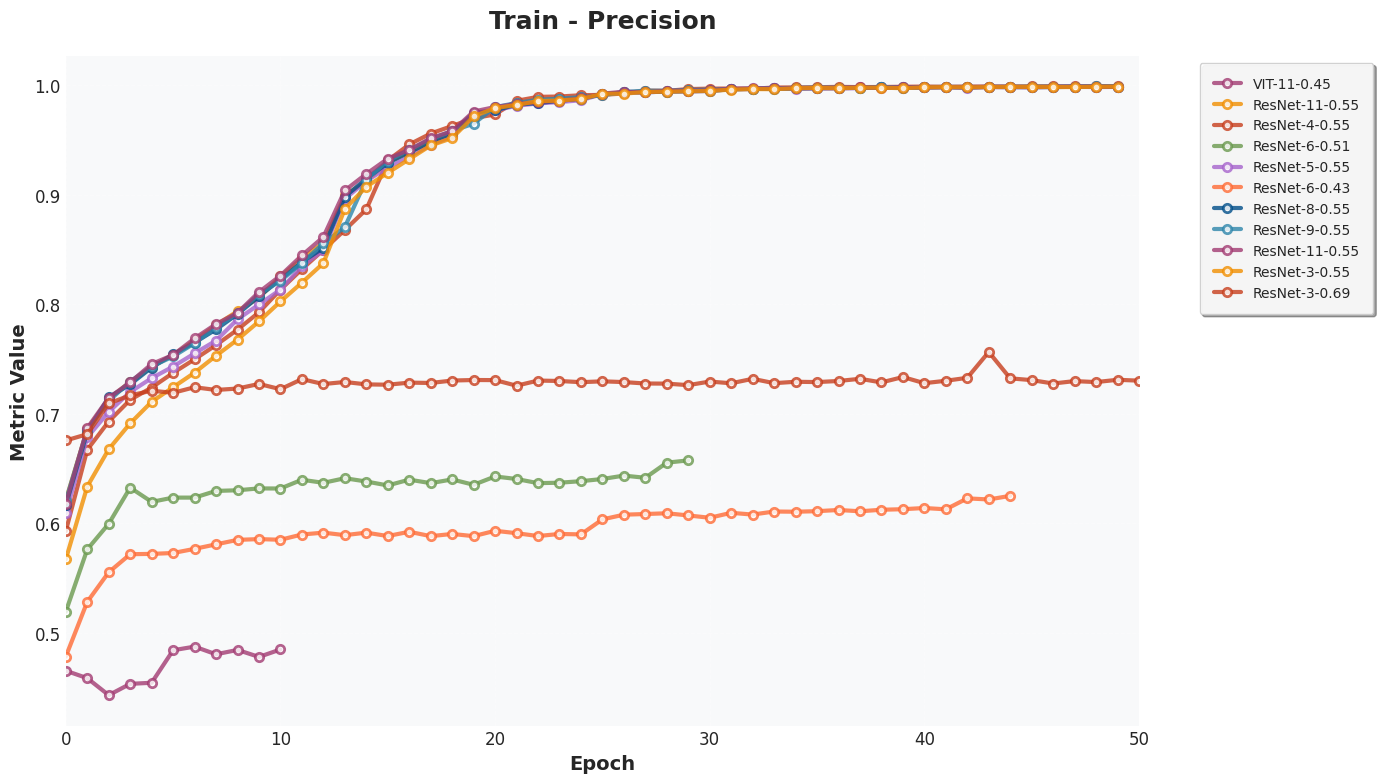

In [236]:
plot_metrics(train_precision_df, max_x_limit=50,title= 'Train - Precision')

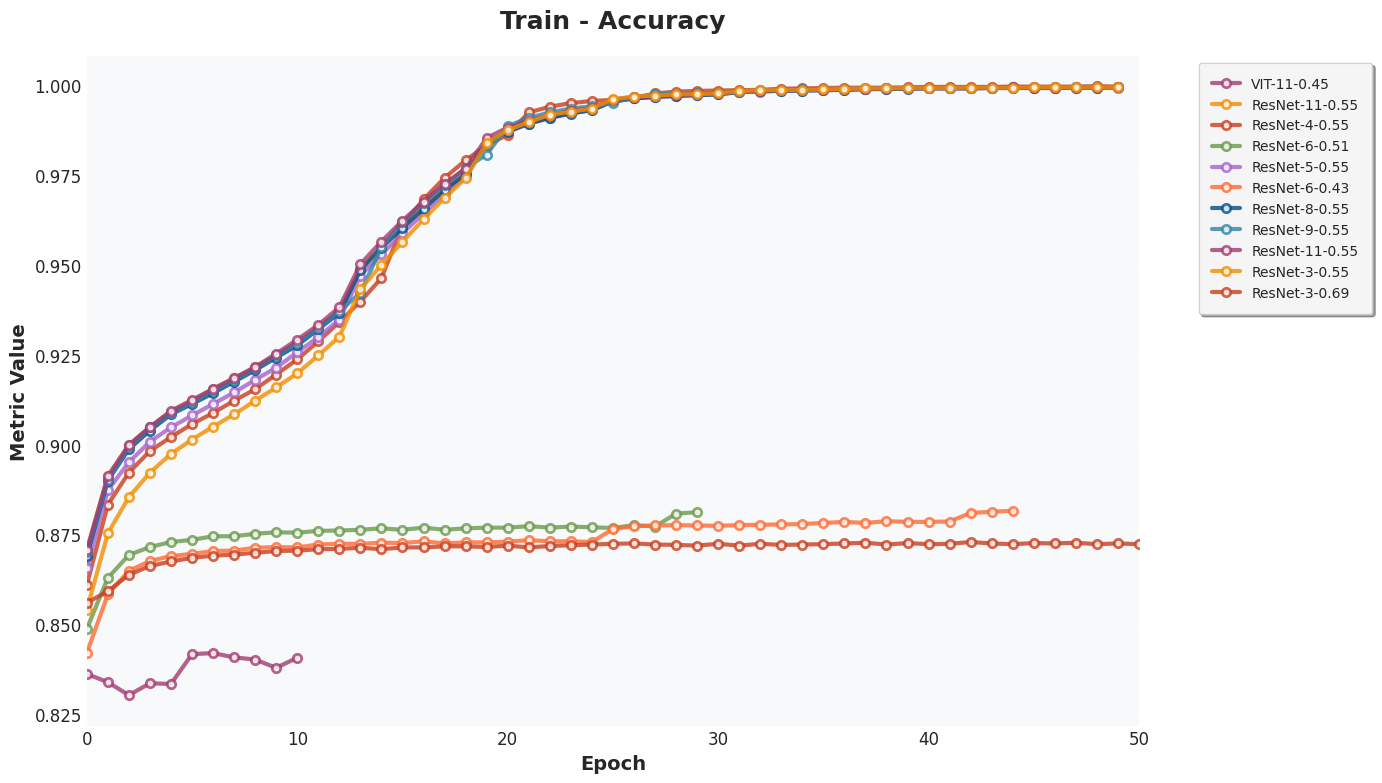

In [242]:
plot_metrics(train_accuracy_df, max_x_limit=50,title= 'Train - Accuracy')

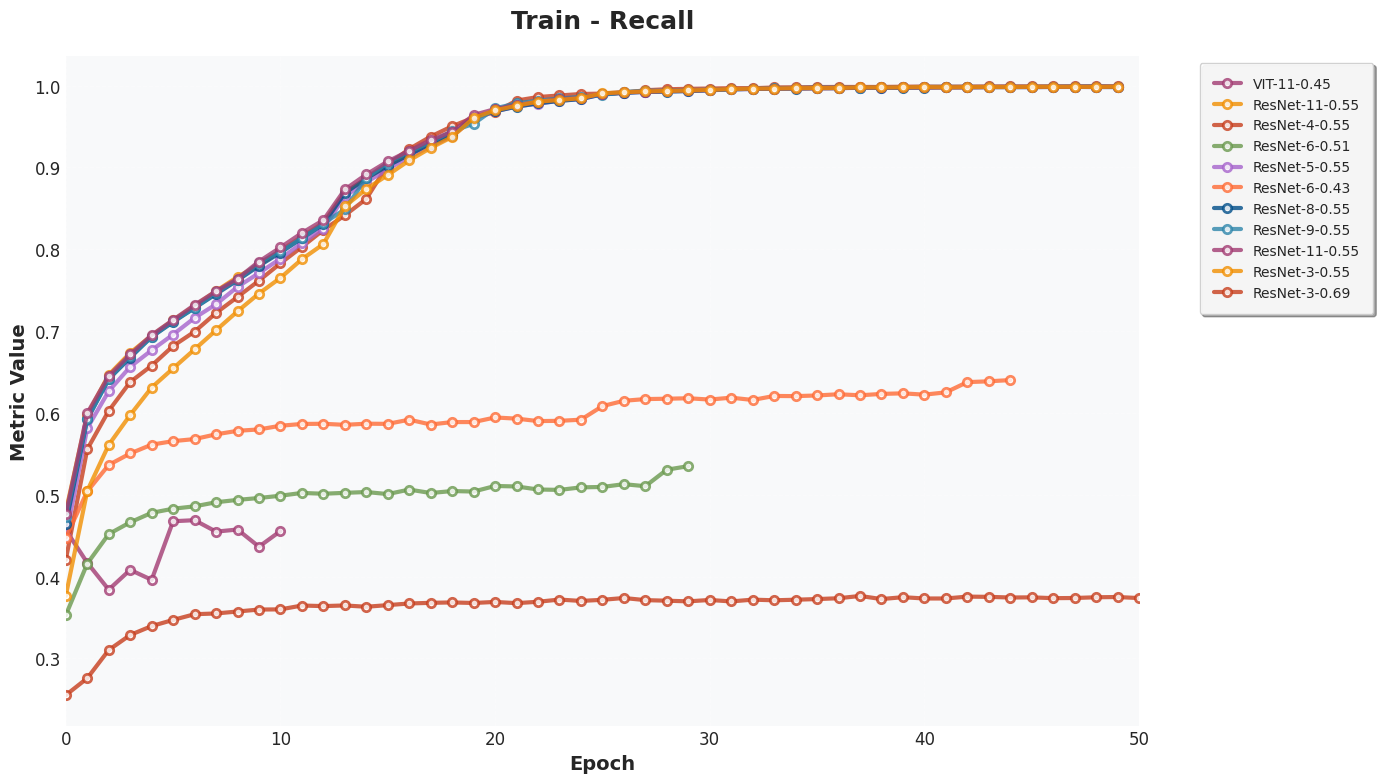

In [243]:
plot_metrics(train_recall_df, max_x_limit=50,title= 'Train - Recall')

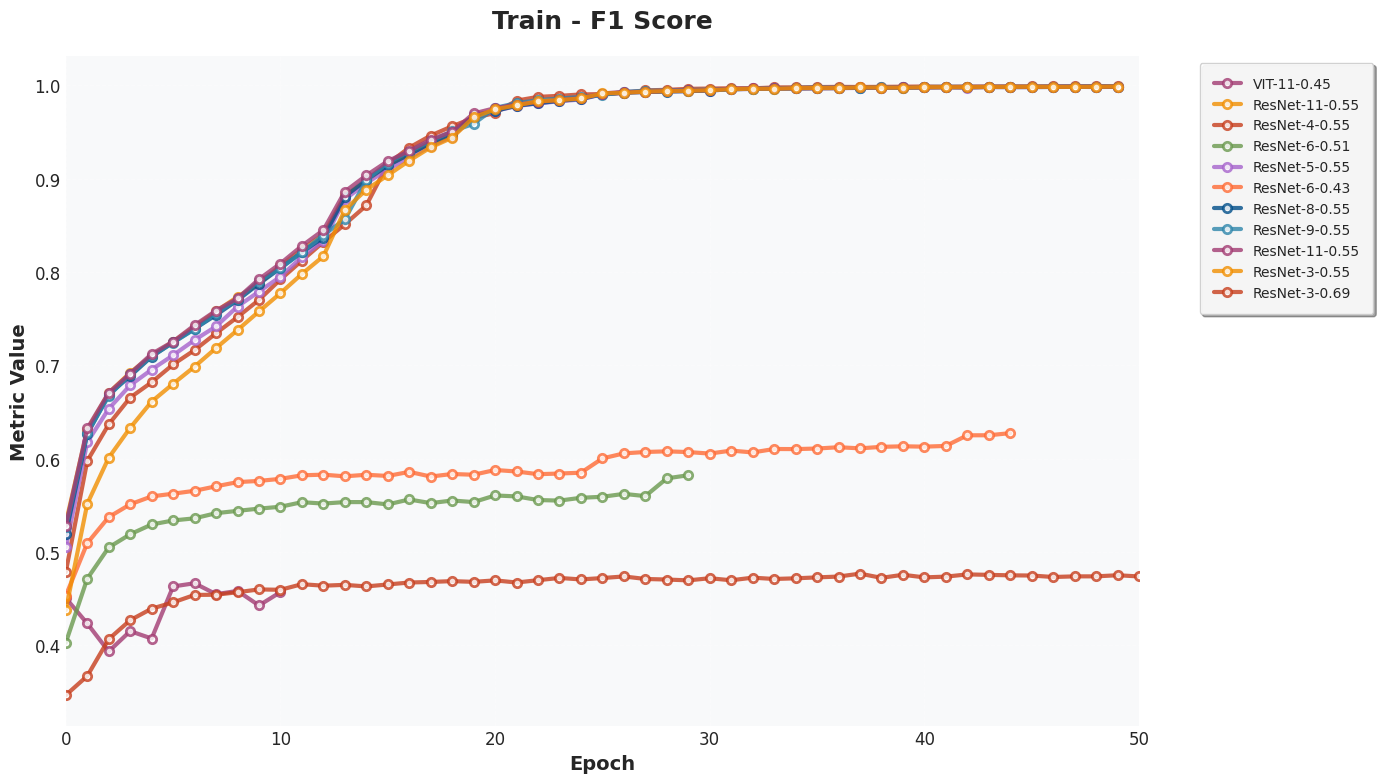

In [244]:
plot_metrics(train_f1_df, max_x_limit=50,title= 'Train - F1 Score')

In [250]:
val_accuracy_df.iloc[:, :-1]

,epoch,"vit_base_patch16_siglip_gap_224/[0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12]/1e-3/0.45/PSTrue","resnet50/[0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 11, 12]/1e-3/0.51/PSTrue","resnet50/[1, 2, 3, 4, 11]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 11, 12]/1e-3/0.43/PSTrue","resnet50/[1, 2, 3, 4, 5, 6, 11, 12]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 5, 6, 7, 11, 12]/1e-3/0.55/PSTrue","resnet50/[1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12]/1e-3/0.55/PSTrue","resnet50/[3, 2, 1]/1e-3/0.55/PSTrue"
0,0.0,0.8336,0.8786,0.8595,0.8433,0.8709,0.8359,0.8717,0.8750,0.8702,0.8581
1,1.0,0.8297,0.8906,0.8726,0.8587,0.8810,0.8559,0.8867,0.8852,0.8886,0.8687
2,2.0,0.8296,0.8911,0.8846,0.8511,0.8803,0.8395,0.8906,0.8896,0.8887,0.8729
3,3.0,0.8182,0.8926,0.8799,0.8645,0.8916,0.8577,0.8957,0.8941,0.8966,0.8787
4,4.0,0.8369,0.8983,0.8904,0.8619,0.8920,0.8525,0.8974,0.8953,0.9000,0.8884
...,...,...,...,...,...,...,...,...,...,...,...
75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


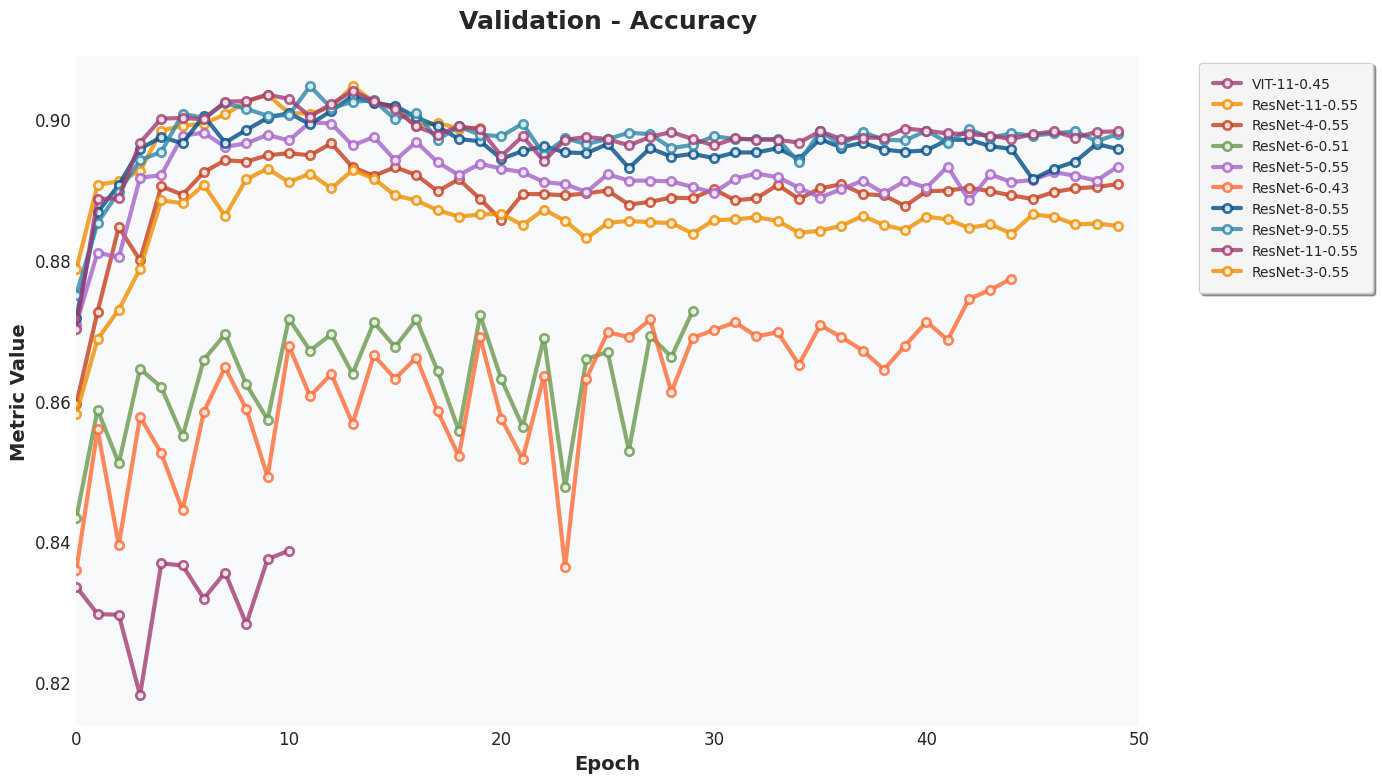

In [251]:
plot_metrics(val_accuracy_df.iloc[:, :-1], max_x_limit=50,title= 'Validation - Accuracy')

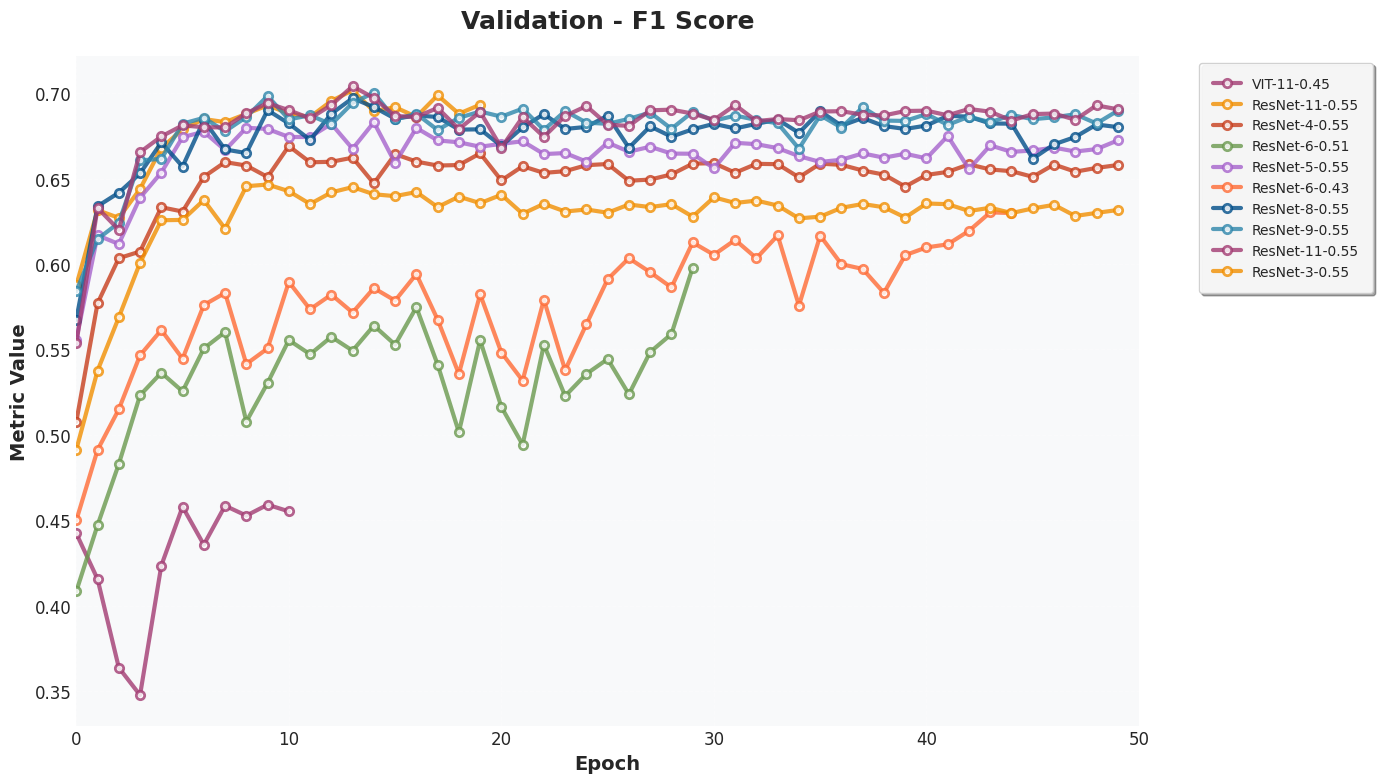

In [252]:
plot_metrics(val_f1_df.iloc[:, :-1], max_x_limit=50,title= 'Validation - F1 Score')

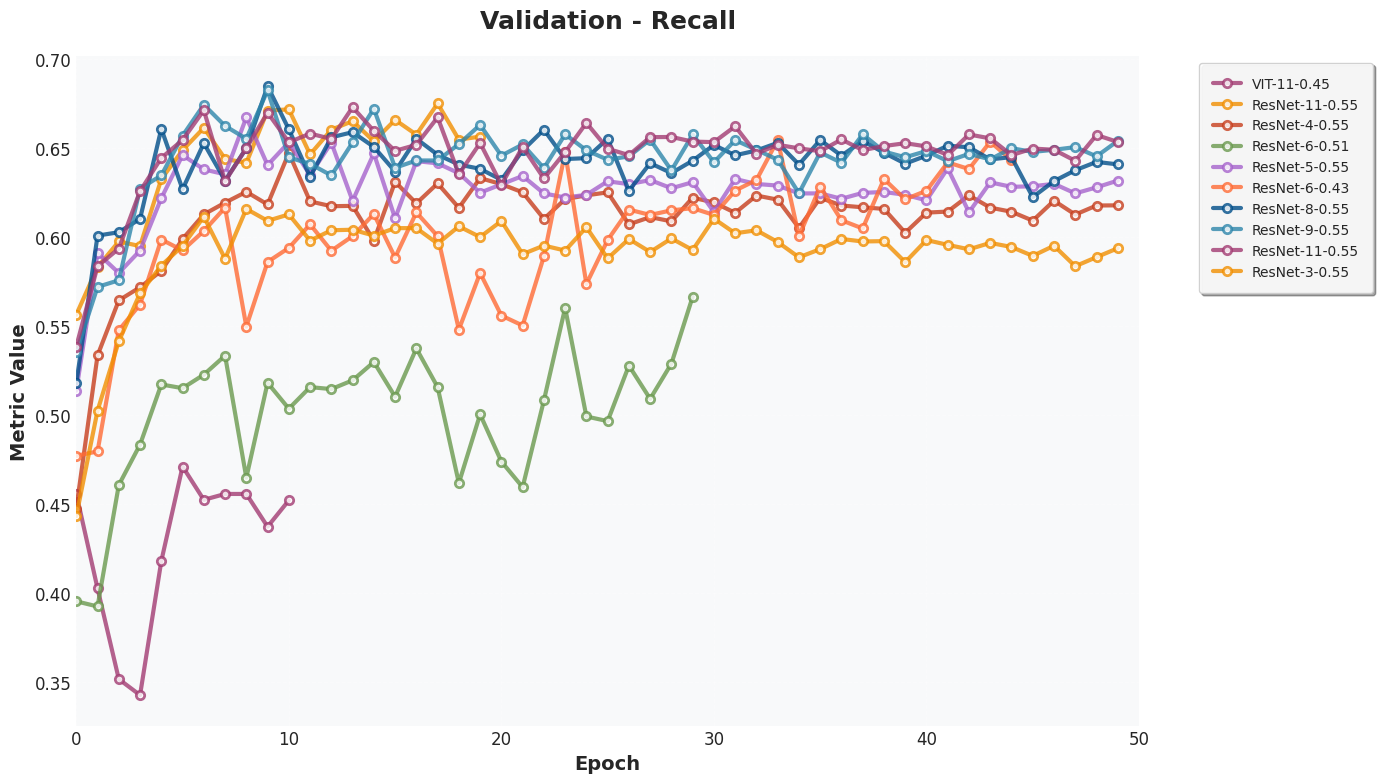

In [253]:
plot_metrics(val_recall_df.iloc[:, :-1], max_x_limit=50,title= 'Validation - Recall')

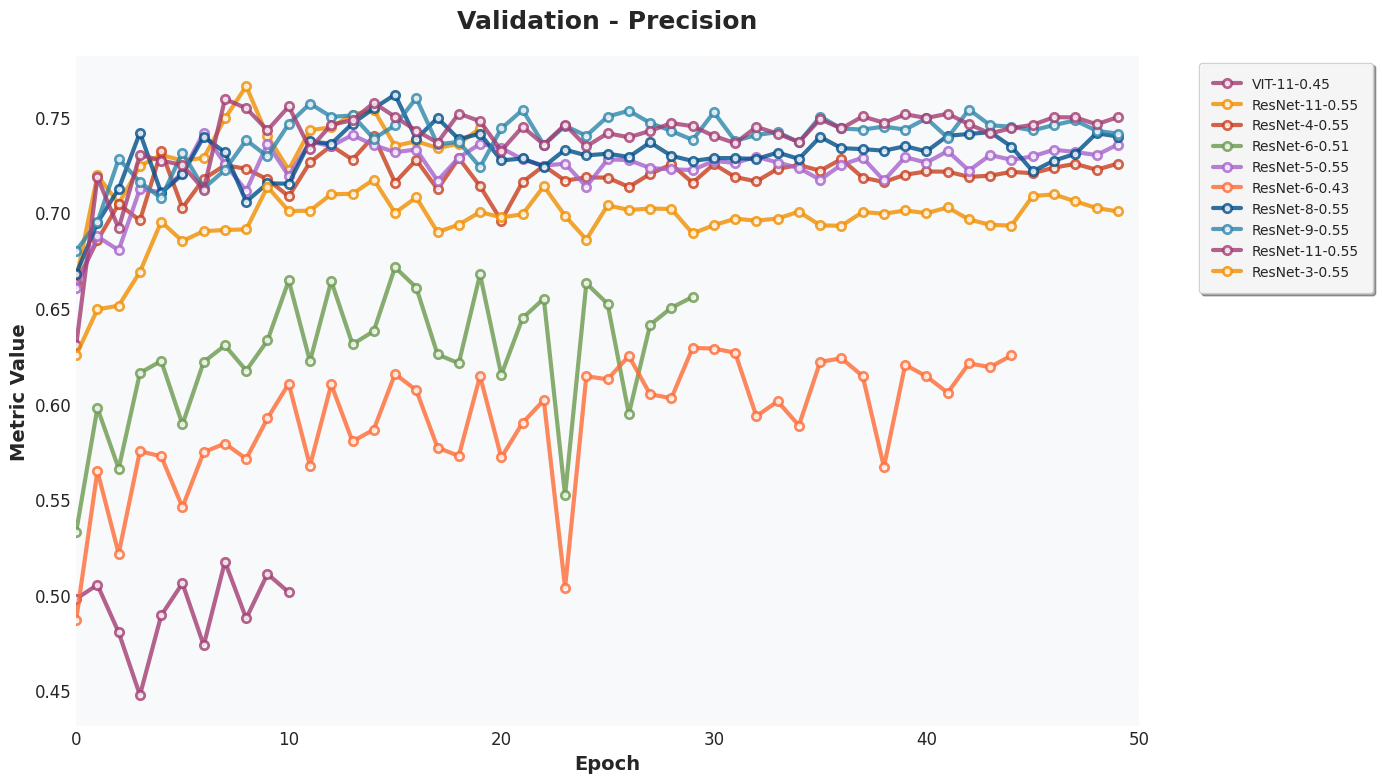

In [262]:
plot_metrics(val_precision_df.iloc[:, :-1], max_x_limit=50,title= 'Validation - Precision')

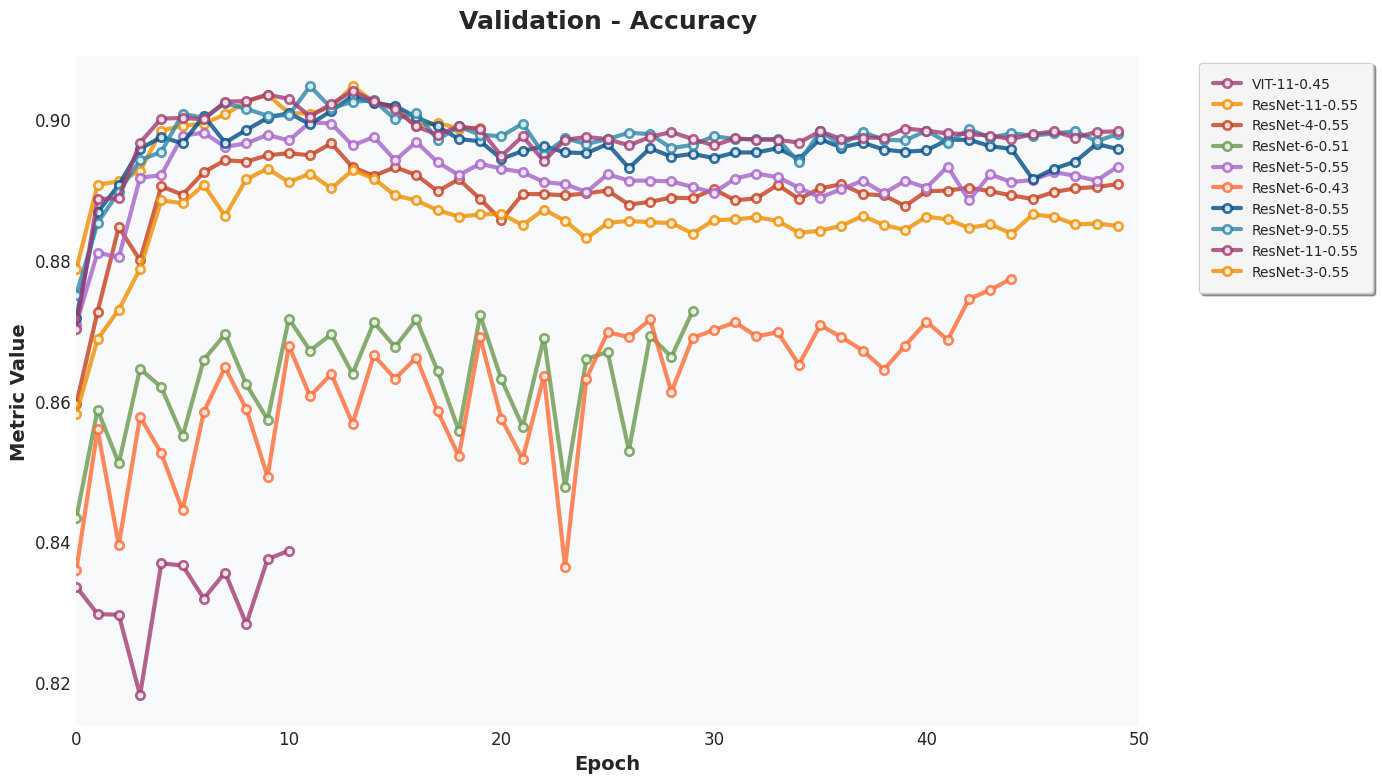

In [263]:
plot_metrics(val_accuracy_df.iloc[:, :-1], max_x_limit=50,title= 'Validation - Accuracy')

In [ ]:
dataframes_list = [
    ("train_f1_df", train_f1_df),
    ("val_f1_df", val_f1_df),
    ("train_accuracy_df", train_accuracy_df),
    ("val_accuracy_df", val_accuracy_df),
    ("train_precision_df", train_precision_df),
    ("val_precision_df", val_precision_df),
    ("train_recall_df", train_recall_df),
    ("val_recall_df", val_recall_df),
    ("train_losses_df", train_losses_df),
    ("val_losses_df", val_losses_df)
]

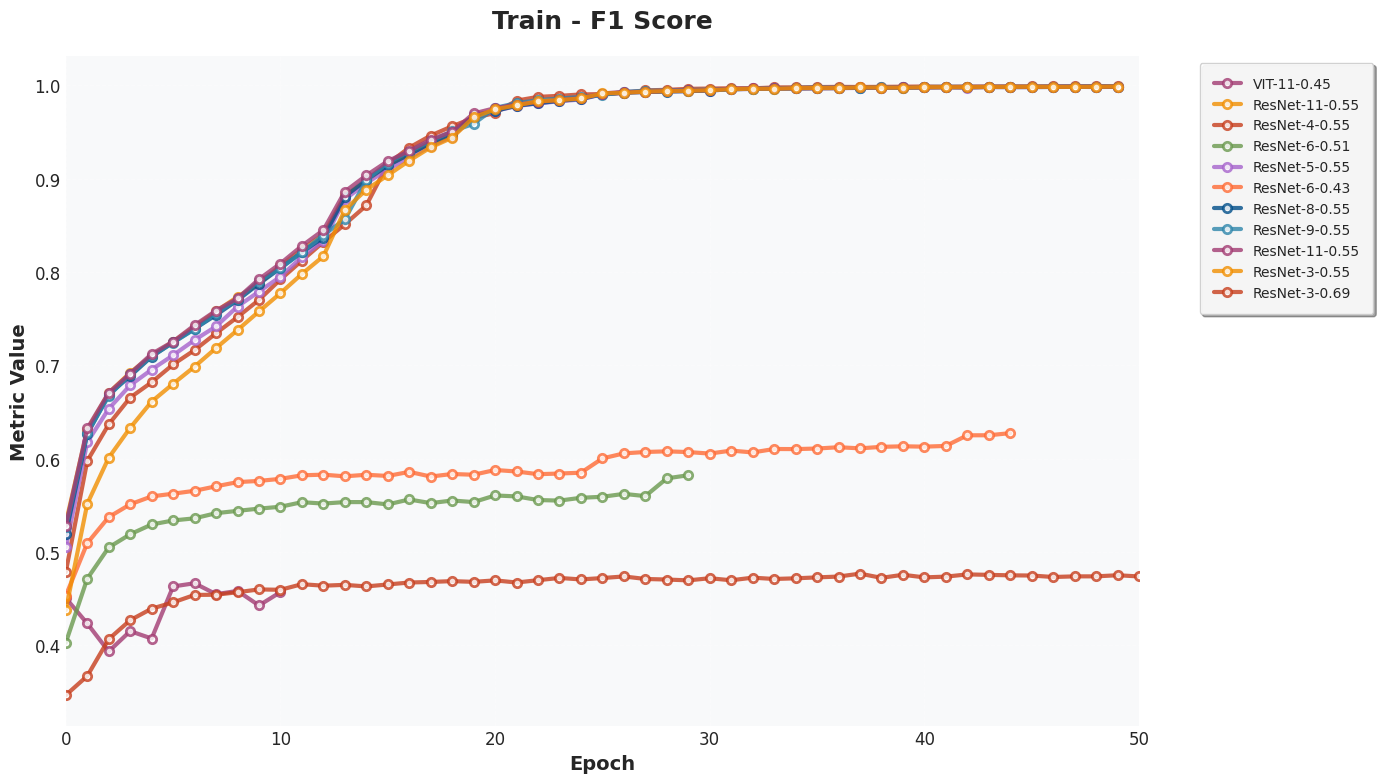

In [239]:
plot_metrics(train_f1_df, max_x_limit=50, title="Train - F1 Score")